In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "font.size": 10,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300,
    "lines.linewidth": 1.5,
    "mathtext.fontset": "stix" # 使公式更接近 Times 风格
})
formatter = ScalarFormatter(useMathText=True)
import numpy as np
import json
import os

# 线型与标记组合
styles = [
    {'ls': '-',  'marker': 'o', 'ms': 4, 'markevery': 5},
    {'ls': '--', 'marker': 's', 'ms': 4, 'markevery': 5},
    {'ls': '-.', 'marker': '^', 'ms': 5, 'markevery': 5},
    {'ls': ':',  'marker': 'D', 'ms': 4, 'markevery': 5},
    {'ls': '-',  'marker': 'v', 'ms': 5, 'markevery': 5}
]
colors = ['#000000', '#D55E00', '#0072B2', '#009E73', '#CC79A7']
name  = ['CocycleNet', 'DeepKoopman', "LRAN"]


In [2]:
from dataset.Meta import DATA_META
def load_json(path):
    with open(path,"r", encoding='utf-8') as f1:
        data = json.load(f1)
    return np.array(data["curves"]['rmse_mean']), np.array(data["curves"]['rmse_std'])

In [ ]:
# shape: [T, 3]
pred_10 = l63_stat_pre.reshape(-1, 3)[:1100]
true_10 = l63_stat_true.reshape(-1, 3)[:1100]

pred_90 = l63_stat_pre.reshape(-1, 3)[:9900]
true_90 = l63_stat_true.reshape(-1, 3)[:9900]

var_names = [r"$x$", r"$y$", r"$z$"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# -------- 第一行：10 Lyapunov 时间 --------
for i in range(3):
    ax = axes[0, i]

    true_i = true_10[:, i]
    pred_i = pred_10[:, i]

    data_min = min(true_i.min(), pred_i.min())
    data_max = max(true_i.max(), pred_i.max())
    x_grid = np.linspace(data_min, data_max, 500)

    kde_true = gaussian_kde(true_i)
    kde_pred = gaussian_kde(pred_i)

    ax.plot(x_grid, kde_true(x_grid), label="True")
    ax.plot(x_grid, kde_pred(x_grid), linestyle="--", label="Pred")

    ax.fill_between(x_grid, kde_true(x_grid), alpha=0.15)
    ax.fill_between(x_grid, kde_pred(x_grid), alpha=0.15)

    ax.set_title(var_names[i])
    # ax.set_ylabel("Density")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if i == 0:
        ax.legend(frameon=False)

# -------- 第二行：90 Lyapunov 时间 --------
for i in range(3):
    ax = axes[1, i]

    true_i = true_90[:, i]
    pred_i = pred_90[:, i]

    data_min = min(true_i.min(), pred_i.min())
    data_max = max(true_i.max(), pred_i.max())
    x_grid = np.linspace(data_min, data_max, 500)

    kde_true = gaussian_kde(true_i)
    kde_pred = gaussian_kde(pred_i)

    ax.plot(x_grid, kde_true(x_grid))
    ax.plot(x_grid, kde_pred(x_grid), linestyle="--")

    ax.fill_between(x_grid, kde_true(x_grid), alpha=0.15)
    ax.fill_between(x_grid, kde_pred(x_grid), alpha=0.15)

    # ax.set_ylabel("Density")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0, 0].set_ylabel("Density\n(10 LT)")
axes[1, 0].set_ylabel("Density\n(90 LT)")

plt.tight_layout()
plt.show()
fig.savefig('test_results/Lorenz/l63_stat.png', dpi=300, bbox_inches="tight")

NameError: name 'l63_stat_pre' is not defined

#### Ablation experiments

In [72]:
def plot_rmse(ax, CN_C_mean, CN_C_std, DK_mean, DK_std, LRAN_mean, LRAN_std, title, Meta, downsample):
    # fig, ax = plt.subplots(figsize=(5.1, 3.5))
    
    # 计算时间轴
    dt = Meta.deltat * downsample * Meta.mle
    steps = CN_C_mean.shape[0]
    x = np.arange(steps) * dt

    ax.plot(x, CN_C_mean, label='CocycleNet', color=colors[0], **styles[0], lw=1.5)
    ax.fill_between(x, np.maximum(0, CN_C_mean - CN_C_std), CN_C_mean + CN_C_std, 
                    color=colors[0], alpha=0.15, edgecolor='none')

    # ax.plot(x, CN_R_mean, label='CocycleNet-R', color=colors[1], **styles[1], lw=1.5)
    # ax.fill_between(x, np.maximum(0, CN_R_mean - CN_R_std), CN_R_mean + CN_R_std, 
    #                 color=colors[1], alpha=0.15, edgecolor='none')
    ax.plot(x[:DK_mean.shape[0]], DK_mean, label='DeepKoopman', color=colors[1], **styles[1], lw=1.5)
    ax.fill_between(x[:DK_mean.shape[0]], np.maximum(0, DK_mean - DK_std), DK_mean + DK_std, 
                    color=colors[1], alpha=0.15, edgecolor='none')

    ax.plot(x, LRAN_mean, label='LRAN', color=colors[2], **styles[2], lw=1.5)
    ax.fill_between(x, np.maximum(0, LRAN_mean - LRAN_std), LRAN_mean + LRAN_std, 
                    color=colors[2], alpha=0.15, edgecolor='none')
    # --- 4. 细节润色 ---
    ax.grid(True, linestyle='--', alpha=0.3) # 更加正式的网格
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(r'Time $t$ (Lyapunov Time)')
    ax.set_ylabel("RMSE")

    # SIAM 标题通常不加粗，且字体不宜过大，或者直接作为 Figure Caption
    ax.set_title(title, fontsize=11) 

    # 图例去掉边框，位置根据数据调整
    ax.legend(frameon=False, loc="best")

#### Load data

In [ ]:
pen_root = "test_results/Pendulum/"
meta_pen = DATA_META['pendulum']
DK_pen_mean, DK_pen_std = load_json(os.path.join(pen_root,"DK.json"))
LRAN_pen_mean, LRAN_pen_std = load_json(os.path.join(pen_root,"LRAN.json"))
cocycle_pen_mean, cocycle_pen_std = load_json(os.path.join(pen_root,"CocycleNet.json"))


In [ ]:
l63_root = "test_results/Lorenz/"
meta_l63 = DATA_META['l63']
DK_l63_mean, DK_l63_std = load_json(os.path.join(l63_root,"DK.json"))
LRAN_l63_mean, LRAN_l63_std = load_json(os.path.join(l63_root,"LRAN.json"))
cocycle_l63_mean, cocycle_l63_std = load_json(os.path.join(l63_root,"Cocycle-C_k1_10.json"))

In [ ]:
ks_root = "test_results/KS/"
meta_ks = DATA_META['KS']
DK_ks_mean, DK_ks_std = load_json(os.path.join(ks_root,"DK.json"))
LRAN_ks_mean, LRAN_ks_std = load_json(os.path.join(ks_root,"LRAN.json"))
cocycle_ks_mean, cocycle_ks_std = load_json(os.path.join(ks_root,"CocycleNet.json"))


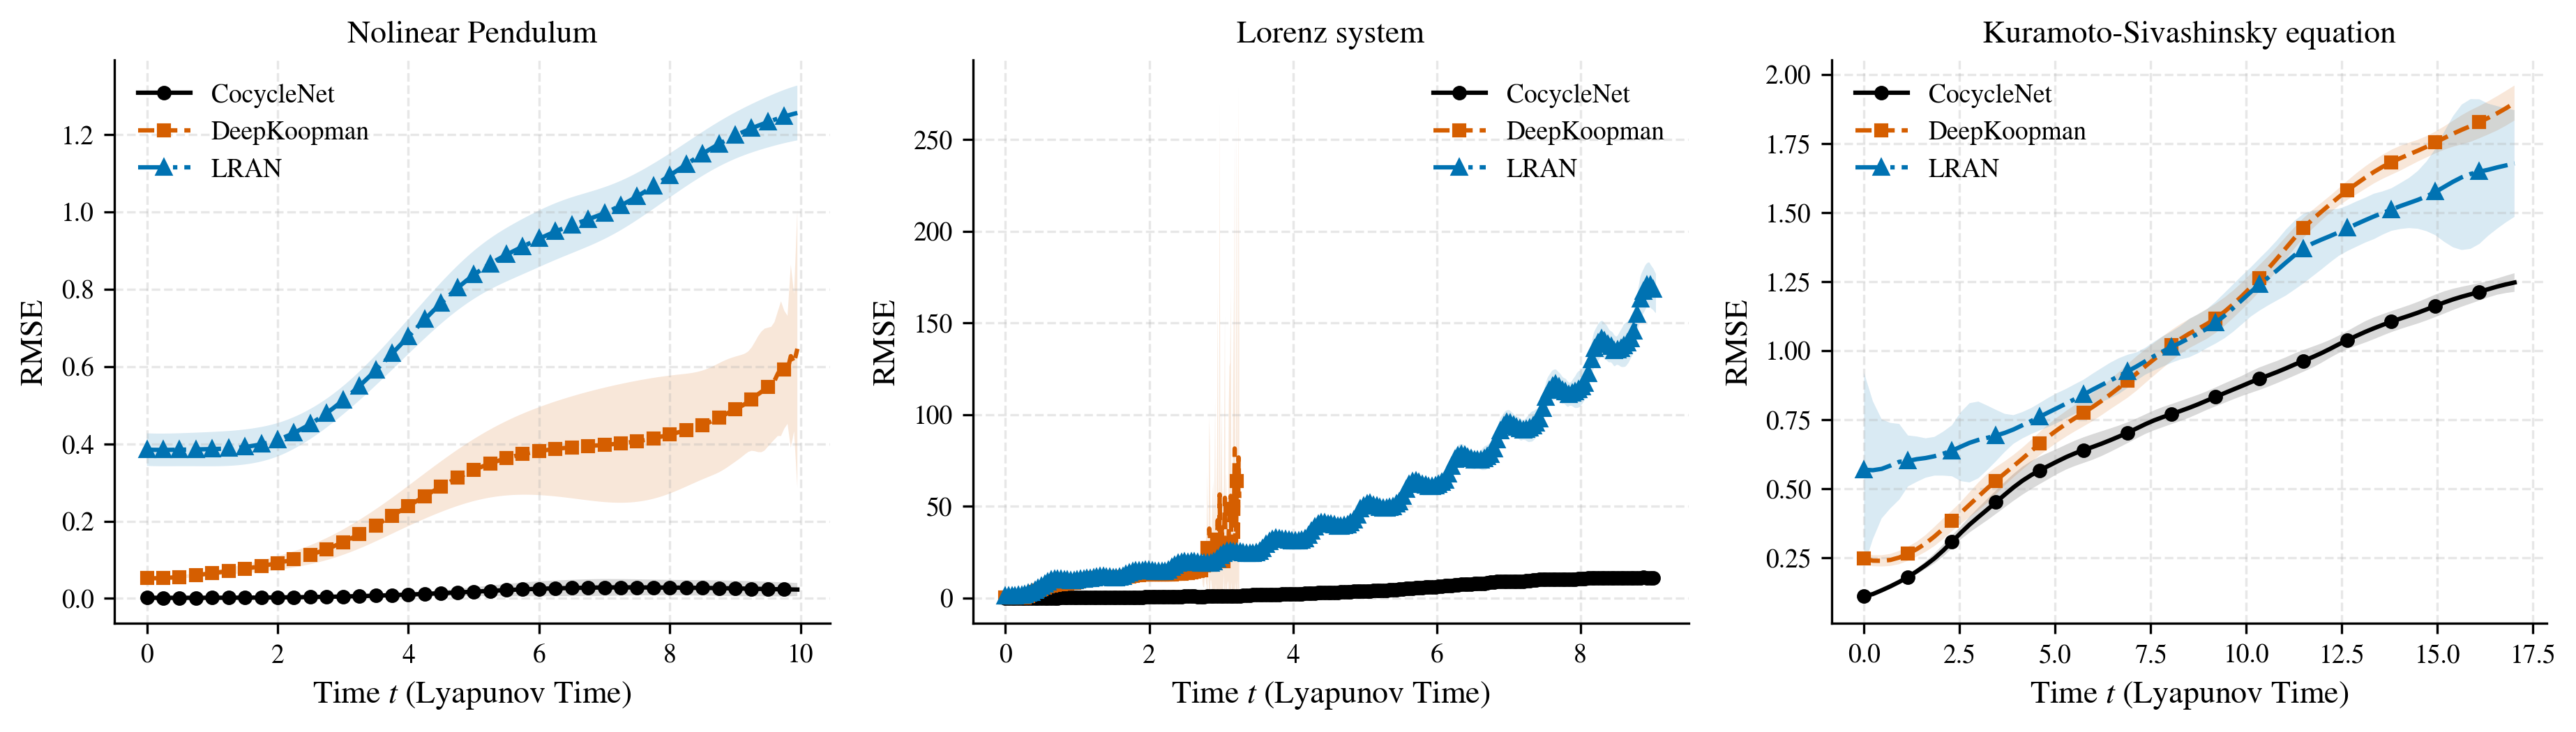

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5),
                             squeeze=False)  # 保证 axes 始终是二维数组
plot_rmse(axes[0,0], cocycle_pen_mean, cocycle_pen_std, DK_pen_mean, DK_pen_std, LRAN_pen_mean, LRAN_pen_std, "Nolinear Pendulum", meta_pen, 5 )
plot_rmse(axes[0,1], cocycle_l63_mean, cocycle_l63_std,  DK_l63_mean[:360], DK_l63_std[:360], LRAN_l63_mean, LRAN_l63_std, "Lorenz system", meta_l63, 1 )
plot_rmse(axes[0,2], cocycle_ks_mean, cocycle_ks_std, DK_ks_mean, DK_ks_std, LRAN_ks_mean, LRAN_ks_std, "Kuramoto-Sivashinsky equation", meta_ks, 4 )
fig.savefig('test_results/rmse.png', dpi=300, bbox_inches="tight")

## Visualization of prediction results on test dataset

In [ ]:
from exp import NeuralModel
from data_provider.data_loader import DataModule
import yaml
def flatten_dict(d, parent_key="", sep="_"):
    items = {}
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.update(flatten_dict(v, new_key, sep))
        else:
            items[new_key] = v
    return items

from argparse import Namespace

def load_config(path):
    with open(path) as f:
        cfg = yaml.safe_load(f)
    return Namespace(**flatten_dict(cfg))


Seed set to 2025


In [ ]:
def compute_vpt(pred, true, threshold, dt=1.0):

    # RMSE per dimension
    error = np.sqrt(np.mean((pred - true)**2,axis=-1))  # (batch, step)
    print(error)
    exceed = error >= threshold

    vpt_indices = np.argmax(exceed, axis=1)

    any_exceed = np.any(exceed, axis=1)

    vpt_indices = np.where(any_exceed, vpt_indices, error.shape[1])

    vpt_values = vpt_indices * dt 

    return vpt_values

In [ ]:
def plot_joint_distribution_1x4(
    uxx_true, uxxxx_true,
    uxx_models, uxxxx_models,
    model_names,
    save_path=None
):
    """
    uxx_true, uxxxx_true: [N,]
    uxx_models: list of [N,]
    uxxxx_models: list of [N,]
    model_names: list[str], length=3
    """

    # -----------------------
    # 1. 统一范围（非常关键）
    # -----------------------
    all_uxx = [uxx_true] + uxx_models
    all_uxxxx = [uxxxx_true] + uxxxx_models

    xmin = min([x.min() for x in all_uxx])
    xmax = max([x.max() for x in all_uxx])
    ymin = min([y.min() for y in all_uxxxx])
    ymax = max([y.max() for y in all_uxxxx])

    # 可选：裁剪极端值（防止爆炸影响）
    def clip(arr, q=0.995):
        low, high = np.quantile(arr, [1-q, q])
        return np.clip(arr, low, high)

    # uxx_true = clip(uxx_true)
    # uxxxx_true = clip(uxxxx_true)
    # uxx_models = [clip(x) for x in uxx_models]
    # uxxxx_models = [clip(x) for x in uxxxx_models]

    # -----------------------
    # 2. 创建画布
    # -----------------------
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))

    datasets = [(uxx_true, uxxxx_true)] + list(zip(uxx_models, uxxxx_models))
    titles = ["Truth"] + model_names

    # -----------------------
    # 3. 先计算统一 vmax
    # -----------------------
    gridsize = 120
    counts_list = []

    for x, y in datasets:
        counts, _, _ = np.histogram2d(x, y, bins=gridsize)
        counts_list.append(counts)

    vmax = max([c.max() for c in counts_list])

    # -----------------------
    # 4. 绘制
    # -----------------------
    for ax, (x, y), title in zip(axes, datasets, titles):

        hb = ax.hexbin(
            x, y,
            gridsize=gridsize,
            cmap='magma',
            bins='log',   # 关键：log density
            # extent=[xmin, xmax, ymin, ymax],
            vmin=1,
            vmax=vmax
        )

        ax.set_title(title, fontsize=11)
        # ax.set_xlim(xmin, xmax)
        # ax.set_ylim(ymin, ymax)

        ax.tick_params(labelsize=8)

    # -----------------------
    # 5. 统一标签
    # -----------------------
    axes[0].set_ylabel(r"$u_{xxxx}$", fontsize=12)
    for ax in axes:
        ax.set_xlabel(r"$u_{xx}$", fontsize=12)

    # -----------------------
    # 6. Colorbar（统一）
    # -----------------------
    cbar = fig.colorbar(hb, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Log Density", fontsize=10)

    # -----------------------
    # 7. 排版优化（期刊风格）
    # -----------------------
    plt.tight_layout(pad=1.0)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_joint_distribution_with_inset(
    uxx_true, uxxxx_true,
    uxx_models, uxxxx_models,
    model_names,
    save_path=None
):
    """
    带 inset 的 1x4 联合分布图
    """

    # -----------------------
    # 1. Truth范围（核心）
    # -----------------------
    x_min_t, x_max_t = np.percentile(uxx_true, [0.1, 99.9])
    y_min_t, y_max_t = np.percentile(uxxxx_true, [0.1, 99.9])

    # -----------------------
    # 2. 创建画布
    # -----------------------
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))

    datasets = [(uxx_true, uxxxx_true)] + list(zip(uxx_models, uxxxx_models))
    titles = ["Truth"] + model_names

    gridsize = 120

    # -----------------------
    # 3. 统一 density scale（仍然要统一！）
    # -----------------------
    counts_list = []
    for x, y in datasets:
        counts, _, _ = np.histogram2d(x, y, bins=gridsize)
        counts_list.append(counts)

    vmax = max([c.max() for c in counts_list])

    # -----------------------
    # 4. 绘图
    # -----------------------
    for i, (ax, (x, y), title) in enumerate(zip(axes, datasets, titles)):

        # 主图（各自范围）
        hb = ax.hexbin(
            x, y,
            gridsize=gridsize,
            cmap='magma',
            bins='log',
            vmin=1,
            vmax=vmax
        )

        ax.set_title(title, fontsize=11,)
        ax.tick_params(labelsize=8)

        # -----------------------
        # Truth 不画框
        # -----------------------
        # if i == 0:
        #     continue

        # -----------------------
        # 5. 画 truth 范围框
        # -----------------------
        rect = plt.Rectangle(
            (x_min_t, y_min_t),
            x_max_t - x_min_t,
            y_max_t - y_min_t,
            edgecolor='cyan',
            facecolor='none',
            linewidth=1.2,
            linestyle='--'
        )
        ax.add_patch(rect)

        # -----------------------
        # 6. inset（右下角）
        # -----------------------
        axins = inset_axes(
            ax,
            width="35%",
            height="35%",
            loc='lower right',
            borderpad=1
        )

        # 只画 truth 范围内的数据
        mask = (
            (x >= x_min_t) & (x <= x_max_t) &
            (y >= y_min_t) & (y <= y_max_t)
        )

        axins.hexbin(
            x[mask], y[mask],
            gridsize=60,
            cmap='magma',
            bins='log',
            vmin=1,
            vmax=vmax
        )

        axins.set_xlim(x_min_t, x_max_t)
        axins.set_ylim(y_min_t, y_max_t)

        axins.set_xticks([])
        axins.set_yticks([])

        # inset 边框强调
        for spine in axins.spines.values():
            spine.set_edgecolor('white')
            spine.set_linewidth(0.8)

    # -----------------------
    # 7. 标签
    # -----------------------
    axes[0].set_ylabel(r"$u_{xx}$", fontsize=12)
    for ax in axes:
        ax.set_xlabel(r"$u_{x}$", fontsize=12)

    # -----------------------
    # 8. colorbar
    # -----------------------
    cbar = fig.colorbar(hb, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("Log Density", fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout(pad=1.0)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

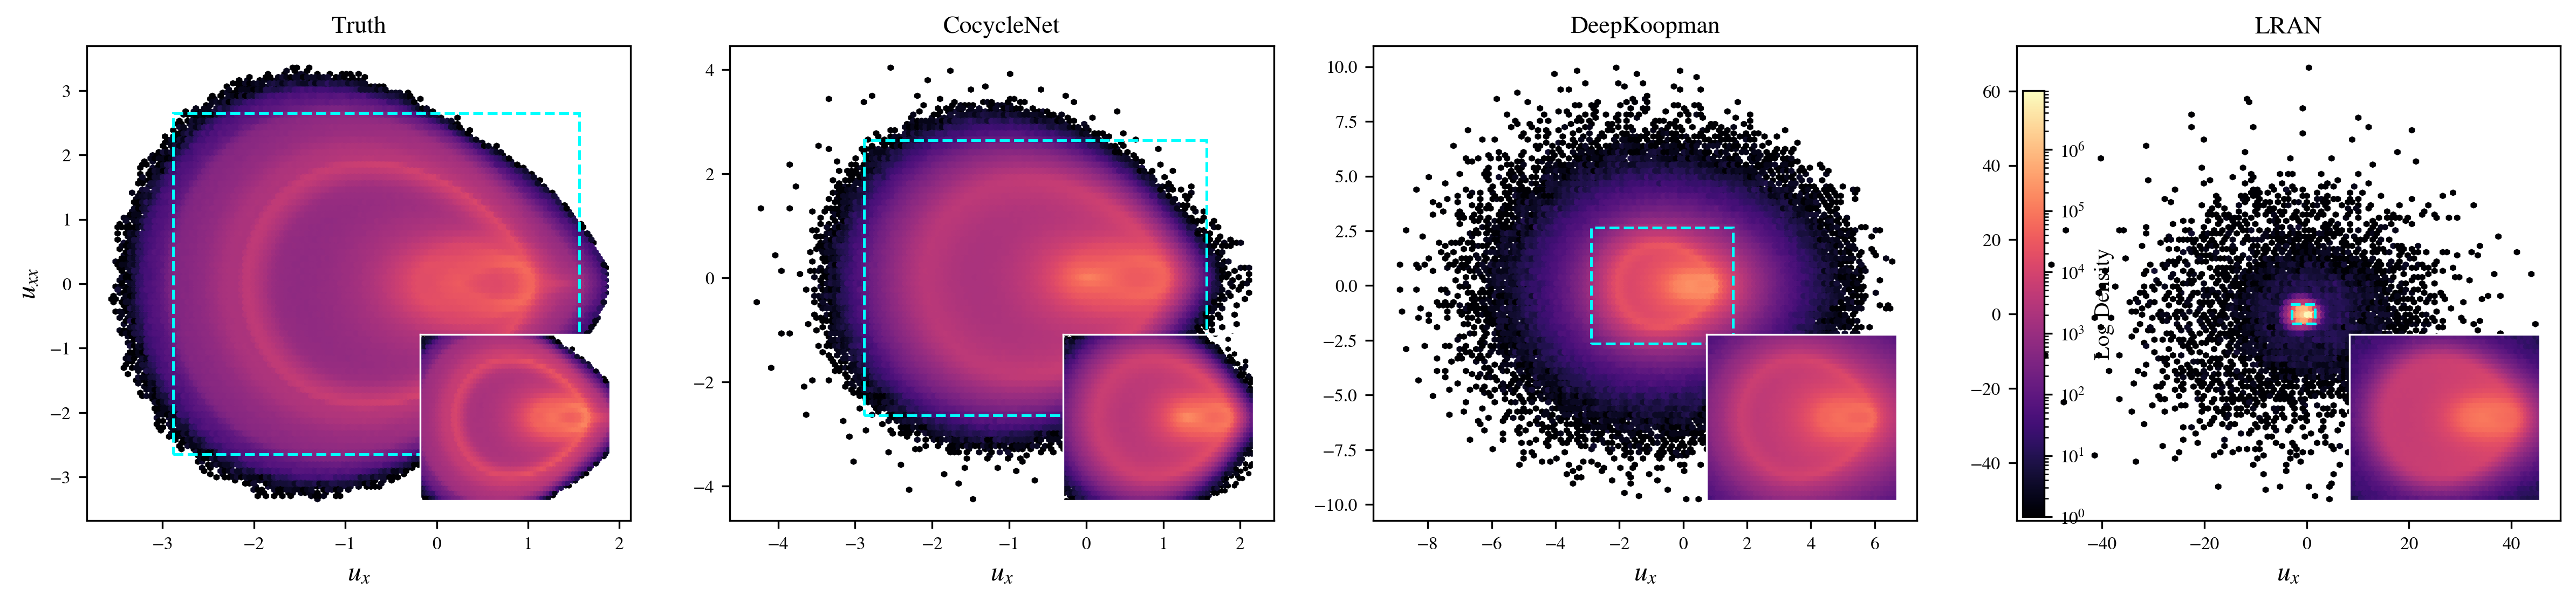

In [ ]:
# 3. flatten
ux_true = ux_true.reshape(-1)
uxx_true = uxx_true.reshape(-1)
uxxxx_true = uxxxx_true.reshape(-1)
ux_models = [
    ux_cn_k2.reshape(-1),
    ux_dk.reshape(-1),
    ux_lran.reshape(-1),
    
]
uxx_models = [
    uxx_cn_k2.reshape(-1),
    uxx_dk.reshape(-1),
    uxx_lran.reshape(-1),
    
]

uxxxx_models = [
    uxxxx_cn_k2.reshape(-1),
    uxxxx_dk.reshape(-1),
    uxxxx_lran.reshape(-1),
    
]

plot_joint_distribution_with_inset(
    ux_true, uxx_true,
    ux_models, uxx_models,
    model_names=["CocycleNet","DeepKoopman", "LRAN"],
    save_path="joint_distribution.png"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import os 

# print(os.getcwd())
def concat_with_mpl(image_paths, cols=3):
    plt.rcParams.update({
        "text.usetex": False  # 如果系统安装了 LaTeX 且需要公式，可设为 True
    })
    num_images = len(image_paths)
    rows = (num_images + cols - 1) // cols
    
    # 1. 预读图片并计算宽高比 (Width / Height)
    imgs = [mpimg.imread(path) for path in image_paths]
    aspect_ratios = [img.shape[1] / img.shape[0] for img in imgs]
    
    # 2. 创建画布
    # 这里的 figsize 宽度可以根据总的宽高比累加动态计算，高度固定
    avg_aspect = sum(aspect_ratios) / num_images
    fig = plt.figure(figsize=(5 * cols * avg_aspect, 5 * rows), dpi=600)
    
    # 3. 按行处理，确保每一行内的图片高度对齐
    for r in range(rows):
        start_idx = r * cols
        end_idx = min(start_idx + cols, num_images)
        row_aspects = aspect_ratios[start_idx:end_idx]
        
        # 为当前行创建子网格，关键在于 width_ratios
        # 它会让宽高比大的图片占据更宽的格子，从而保持所有图高度一致
        gs_main = gridspec.GridSpec(rows, 1)
        gs = gridspec.GridSpecFromSubplotSpec(
            1, len(row_aspects), 
            subplot_spec=gs_main[r],
            width_ratios=row_aspects,
            wspace=0.1 # 子图间的横向间距
        )
        
        for c, idx in enumerate(range(start_idx, end_idx)):
            ax = fig.add_subplot(gs[c])
            ax.imshow(imgs[idx])
            
            # 标注 (a), (b)...
            # 使用负数坐标确保标签在图外左上角，不受图片比例影响
            label = f"({chr(97 + idx)})"
            ax.text(-0.02, 0.95, label, transform=ax.transAxes, 
                    fontsize=10, fontweight='bold', va='bottom', ha='right')
            
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('consistent_height_plot.png', format='png', bbox_inches='tight', dpi=300)
    plt.show()


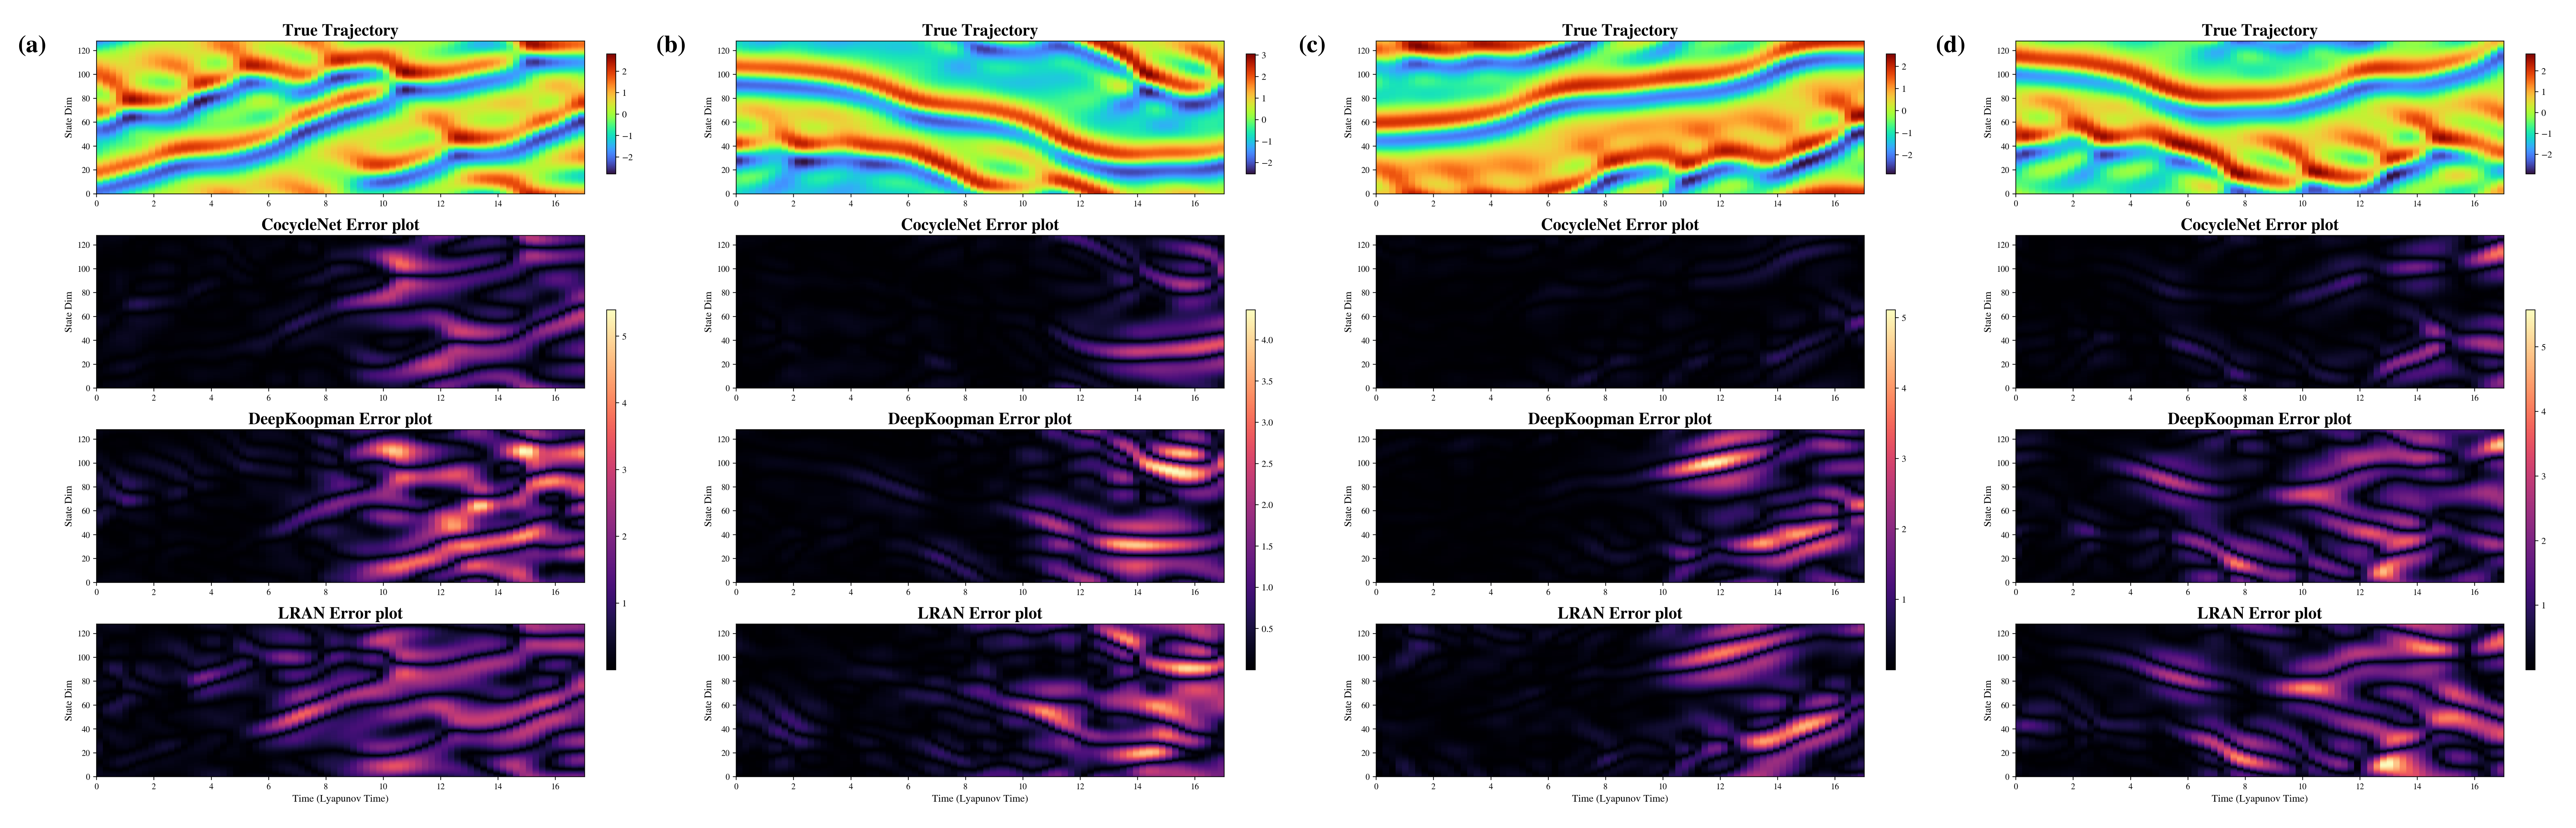

In [79]:
ks_path = './test_results/KS/figures'
image_files = [os.path.join(ks_path, f"{i}th_batch.png") for i in [29,6,10,28]]  # 替换为你的文件列表
concat_with_mpl(image_files,cols=4)

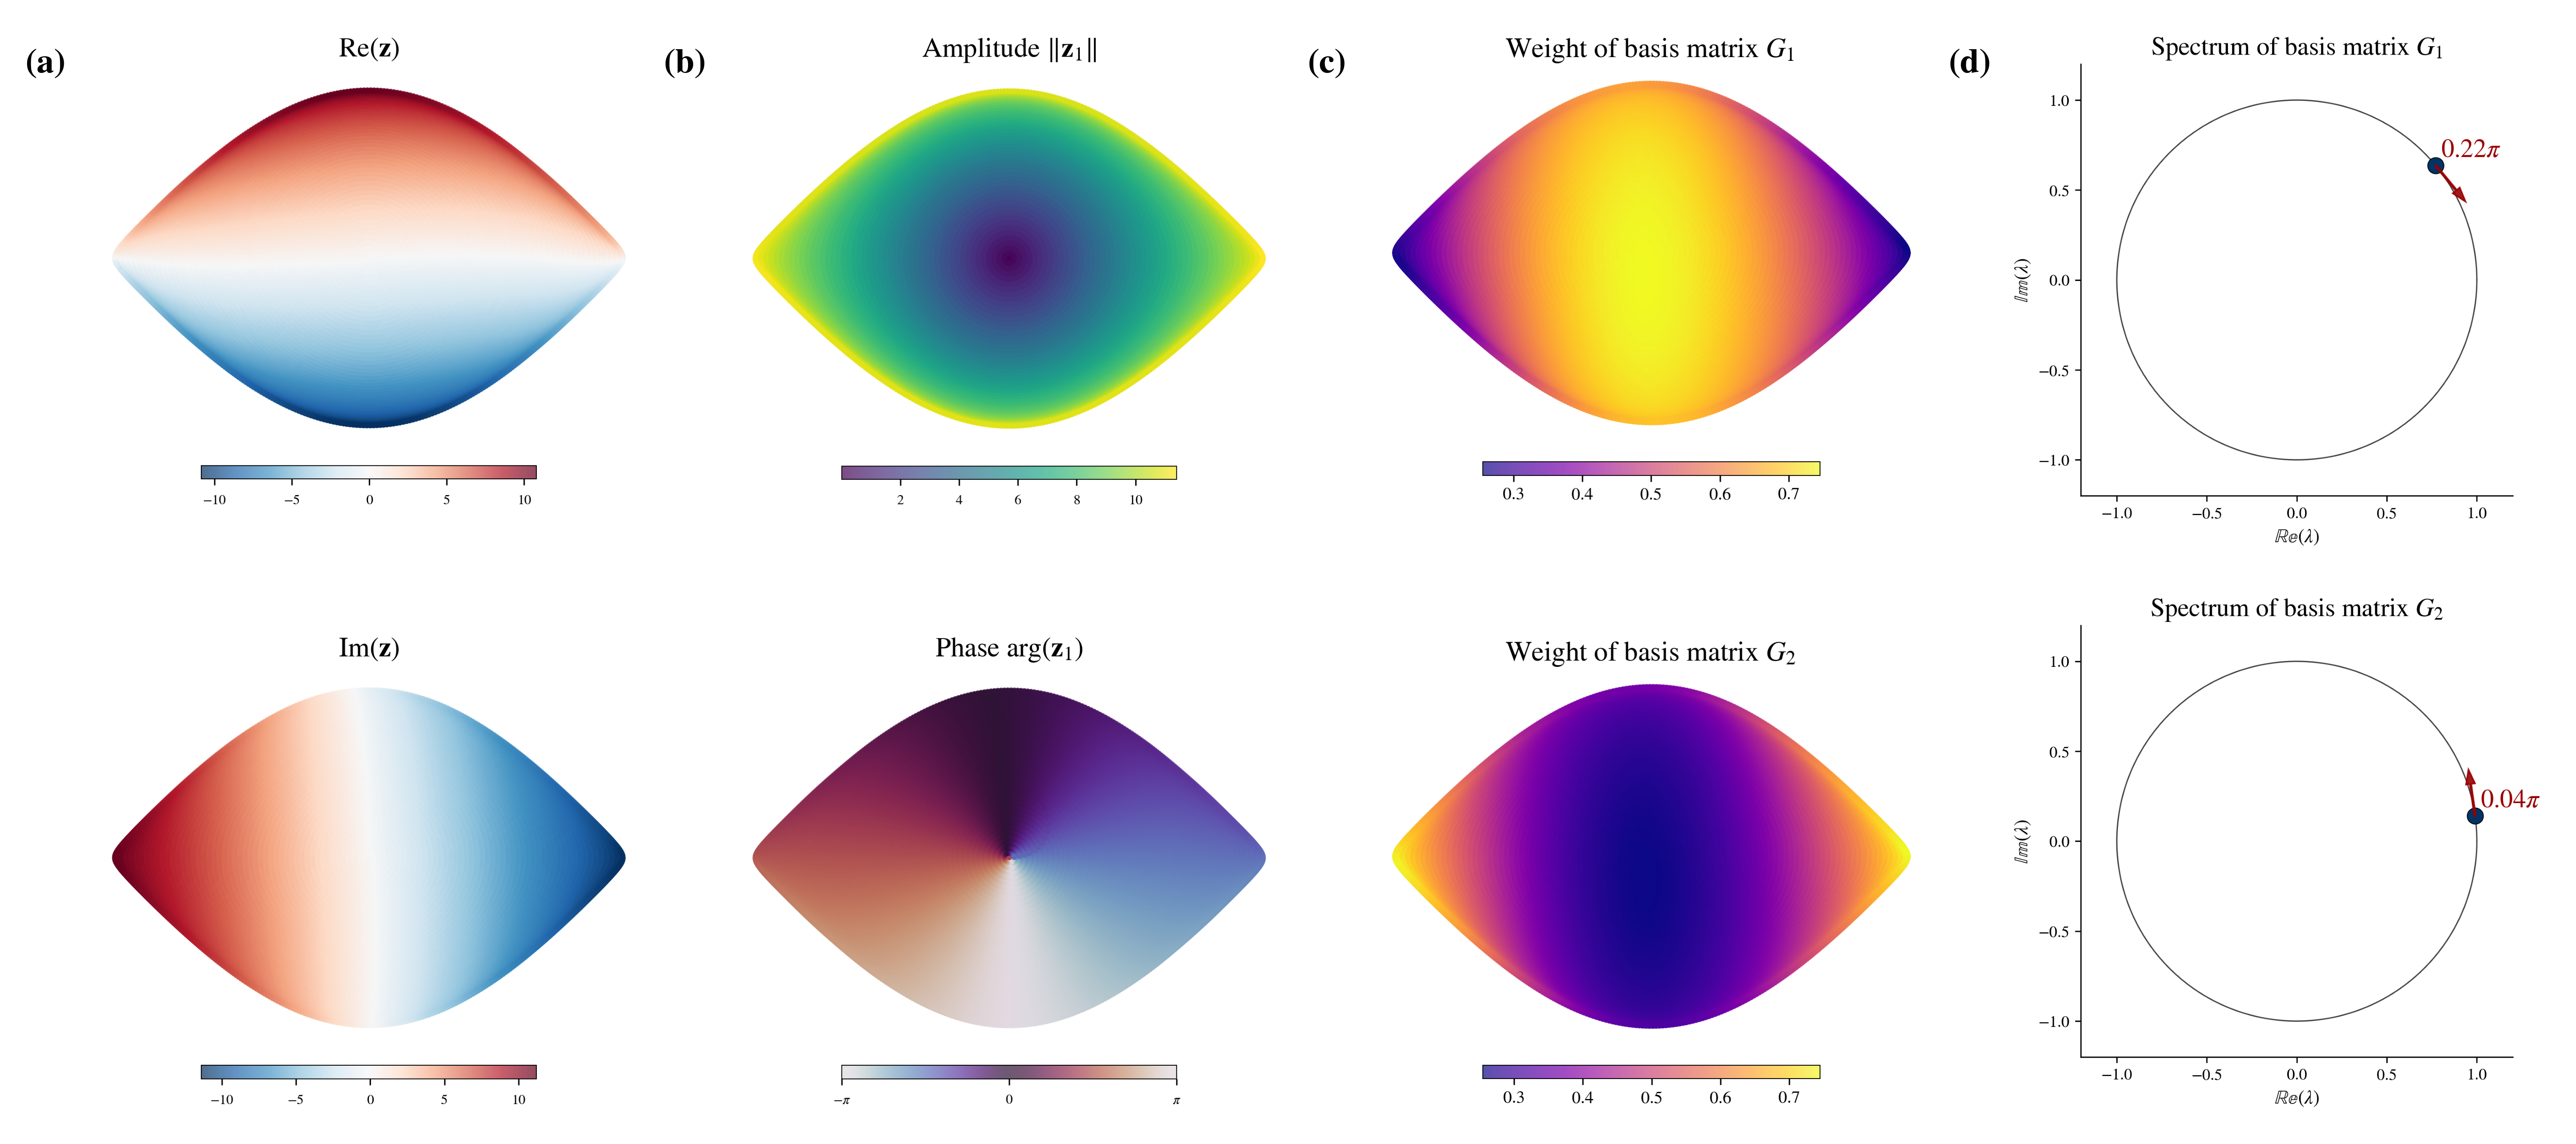

In [ ]:
pen_path = './test_results/Pendulum/figures'
image_files = [os.path.join(pen_path, f'{i}') for i in ['eigenfunction.png','eigenfunction_mag_phase.png','eigenfunction_Expert weight_phase.png','eigenfunction_Expert weight_spectrum.png'] ] 
concat_with_mpl(image_files,4)